In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Mall_Customers.csv")
df.head(4)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77


In [4]:
x=df[["Annual Income (k$)","Spending Score (1-100)"]]
x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [5]:
x.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

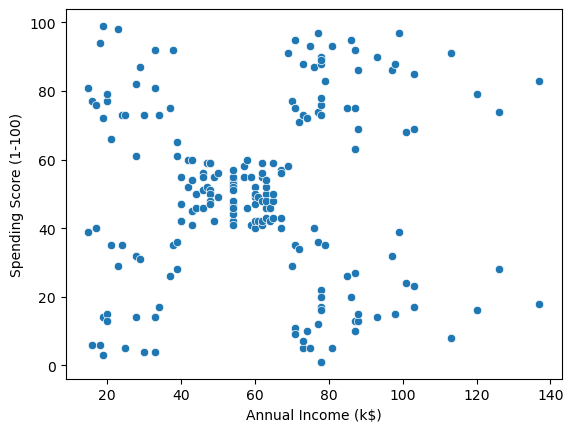

In [6]:
sns.scatterplot(data=x,x="Annual Income (k$)",y="Spending Score (1-100)")

In [9]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_new=pd.DataFrame(ss.fit_transform(x),columns=x.columns)

In [10]:
from sklearn.cluster import KMeans
wcss=[] # keeping intra cluster distance i.e. closeness of datapoints to its centeroid
for i in range(1,10): # hyperparameter tuning to find right number of clusters
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(x_new)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[400.0,
 270.89235946739046,
 157.70400815035947,
 122.85173908250897,
 65.56840815571681,
 55.37581558455638,
 52.231735305583186,
 42.03369214040934,
 32.392267630331176]

Text(0, 0.5, 'WCSS')

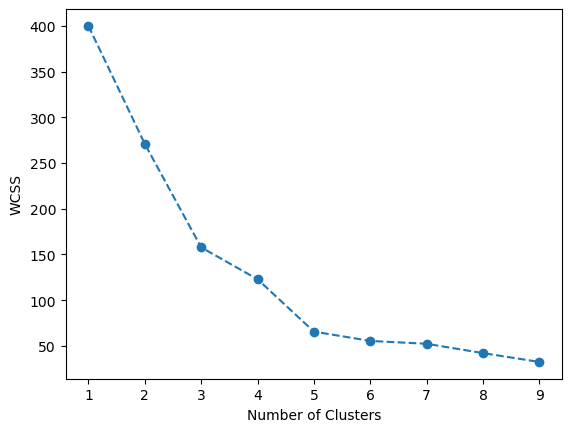

In [13]:
# plotting wcss against number of clusters - 
# for taking elbow method help in deciding how many clusters to take
plt.plot(range(1,10),wcss,"o--")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [24]:
kmeans=KMeans(n_clusters=5)
kmeans.fit(x_new)
pred_labels=kmeans.predict(x_new)

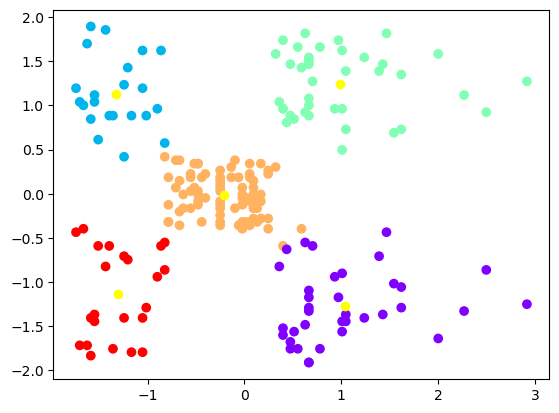

In [25]:
plt.scatter(data=x_new,x="Annual Income (k$)",
            y="Spending Score (1-100)",
            c=pred_labels,cmap="rainbow")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c="yellow")
plt.show()

In [26]:
df["target"]=pred_labels

In [27]:
df["target"].value_counts()

target
3    80
2    39
0    36
4    23
1    22
Name: count, dtype: int64

In [28]:
df.head(7)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),target
0,1,Male,19,15,39,4
1,2,Male,21,15,81,1
2,3,Female,20,16,6,4
3,4,Female,23,16,77,1
4,5,Female,31,17,40,4
5,6,Female,22,17,76,1
6,7,Female,35,18,6,4
